# Semantic Bridge Analysis

## A TACC Computational Cookbook

**Developed by:** Texas Advanced Computing Center (TACC)  
**Institution:** The University of Texas at Austin  
**Contact:** [DSO@tacc.utexas.edu](mailto:DSO@tacc.utexas.edu)

---

### What This Cookbook Does

This tutorial demonstrates how to move from qualitative stakeholder narratives to quantitative scientific framing using natural language processing and lightweight machine learning.

By the end of the workflow, you will be able to:
1. discover themes in stakeholder documents
2. extract decision components such as goals, objectives, variables, and constraints
3. map those themes to scientific domains
4. connect plain-language concepts to scientific variables
5. generate outputs that support downstream decision analysis

Typical use cases include environmental planning, climate adaptation, infrastructure decision support, participatory modeling, and interdisciplinary problem framing.

### Prerequisites

- A TACC account and allocation, or another environment prepared from this repository
- Basic familiarity with Jupyter notebooks and Python
- A set of documents that describe a planning or decision problem

Supported inputs include `.txt`, `.json`, `.docx`, `.pdf`, and common image formats for OCR-based extraction.

### Quick Start

1. Run the setup cells to verify the managed environment.
2. Place source documents in `data/subsidence_groundwater_corpus/raw/` or cleaned text in `data/subsidence_groundwater_corpus/cleaned/`.
3. Work through the topic discovery, science mapping, and decision-component extraction steps.
4. Review the generated figures, tables, and summary report in `outputs/`.

### Expected Outputs

- `*_topic_mappings.csv`: topics linked to scientific domains
- `*_components.csv`: extracted decision components
- `*_svo_mappings.csv`: semantic links to scientific variables
- `*_network.html`: interactive science-backbone visualization
- `*_report.md`: summary report for sharing and review

### Customization

- Update `science_backbone` to reflect your domain structure.
- Expand `svo_vocabulary` with variables relevant to your project.
- Adjust `n_topics` to match the size and diversity of your document set.
- Refine the decision-component extraction patterns for your context.

### Learn More

- [TACC Documentation](https://docs.tacc.utexas.edu)
- [TACC Training](https://learn.tacc.utexas.edu)
- [Science Gateways Community Institute](https://sciencegateways.org/)



In [1]:
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
import spacy
from dotenv import load_dotenv
import nltk
from semantic_bridge.notebook import display as nbutils
from semantic_bridge import api as sbp

SPACY_MODEL_CANDIDATES = ['en_core_web_lg', 'en_core_web_md', 'en_core_web_sm']
nltk.download("punkt_tab")
def get_safe_subprocess_cwd():
    try:
        cwd = Path.cwd()
        if cwd.exists():
            return cwd
    except FileNotFoundError:
        pass

    for fallback in (Path.home(), Path('/tmp')):
        if fallback.exists():
            return fallback

    raise OSError('Could not find a valid working directory for spaCy model installation.')

def load_or_install_spacy_model(model_names):
    for model_name in model_names:
        try:
            return spacy.load(model_name), model_name
        except OSError:
            pass

    install_errors = []
    install_cwd = get_safe_subprocess_cwd()
    for model_name in model_names:
        print(f'spaCy model {model_name} not found. Attempting install from {install_cwd}...')
        try:
            subprocess.run(
                [sys.executable, '-m', 'spacy', 'download', model_name],
                check=True,
                cwd=install_cwd,
            )
            return spacy.load(model_name), model_name
        except Exception as exc:
            install_errors.append(f'{model_name}: {exc}')

    raise OSError(
        'No spaCy English model could be loaded or installed. '
        + ' | '.join(install_errors)
    )

nlp, loaded_model = load_or_install_spacy_model(SPACY_MODEL_CANDIDATES)
print(f'Libraries loaded successfully. spaCy model: {loaded_model}')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home1/06659/wmobley/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Libraries loaded successfully. spaCy model: en_core_web_lg


## Step 2: Prepare Input Data

In this step, you will assemble the document collection, or corpus, that describes the problem you want to analyze.

Typical examples include:
- Interview transcripts
- Meeting notes
- Stakeholder reports
- Grey literature reports
- Community narratives

**Supported formats:**
- `.txt` - Plain text files
- `.json` - JSON with text content (field: `text`, `content`, `body`, or `description`)
- `.docx` - Microsoft Word documents
- `.pdf` - PDFs with extractable text
- `.png` / `.jpg` / `.jpeg` / `.tif` / `.tiff` - Images for OCR extraction

**Corpus sources:**
- Use the local tutorial corpus in `data/subsidence_groundwater_corpus/`
- Or register that corpus as a CKAN dataset and let this notebook download the resources automatically

**Local corpus layout:**
- Put source files in `data/subsidence_groundwater_corpus/raw/`
- Put cleaned text files in `data/subsidence_groundwater_corpus/cleaned/` if you already have them
- The loader will prefer `cleaned/` when both versions exist and otherwise fall back to `raw/`


### Locate the Working Directories

This cell finds the tutorial folder on disk and identifies the local corpus directories the rest of the notebook can use.


In [2]:
tutorial_dir = nbutils.resolve_tutorial_dir()
load_dotenv( 'env.sample', override=False)

corpus_dir = sbp.ensure_data_directory(tutorial_dir / 'data' / 'groundwater-management-area-12')
raw_dir = sbp.ensure_data_directory(corpus_dir / 'raw')
cleaned_dir = sbp.ensure_data_directory(corpus_dir / 'cleaned')
local_data_dir = cleaned_dir if any(cleaned_dir.iterdir()) else raw_dir
analysis_data_dir = local_data_dir

CKAN_URL = os.getenv('CKAN_URL', '').strip()
CKAN_API_TOKEN = os.getenv('CKAN_API_TOKEN', '').strip()
CKAN_DATASET_NAME = "groundwater-management-area-12"

TOPIC_LABELER_MODEL = os.getenv('TOPIC_LABELER_MODEL', '').strip()
TOPIC_LABELER_BASE_URL = os.getenv('OPENAI_BASE_URL', '').strip()
TOPIC_LABELER_API_KEY = os.getenv('OPENAI_API_KEY', '').strip()

MINT_API_BASE_URL = os.getenv('MINT_API_BASE_URL', '').strip()
MINT_USERNAME = os.getenv('MINT_USERNAME', '').strip()
MINT_SVO_PER_PAGE = int(os.getenv('MINT_SVO_PER_PAGE', '200') or '200')
MINT_SVO_MAX_PAGES = int(os.getenv('MINT_SVO_MAX_PAGES', '3') or '3')
MINT_MODEL_PER_PAGE = int(os.getenv('MINT_MODEL_PER_PAGE', '100') or '100')
MINT_MODEL_MAX_PAGES = int(os.getenv('MINT_MODEL_MAX_PAGES', '3') or '3')
MINT_TOPIC_PER_PAGE = int(os.getenv('MINT_TOPIC_PER_PAGE', '100') or '100')
MINT_TOPIC_MAX_PAGES = int(os.getenv('MINT_TOPIC_MAX_PAGES', '3') or '3')


### Optional: Load the Corpus from CKAN

Configuration values such as CKAN URLs, API keys, and external service endpoints are loaded from the tutorial directory `.env` file when present. This keeps the tutorial notebook focused on analysis rather than setup details.

If `CKAN_URL` and `CKAN_DATASET_NAME` are configured, the notebook will fetch the dataset through the CKAN API and cache its resources locally. Otherwise, it will continue using the local tutorial corpus.


In [3]:
if CKAN_URL and CKAN_DATASET_NAME:
    ckan_cache_dir = sbp.ensure_data_directory(corpus_dir / 'ckan_cache')
    ckan_dataset = sbp.fetch_ckan_dataset(CKAN_URL, CKAN_DATASET_NAME)
    downloaded_resources = sbp.sync_ckan_resources_to_directory(
        ckan_dataset,
        ckan_cache_dir,
        base_url=CKAN_URL,

    )
    analysis_data_dir = ckan_cache_dir
    print(f'Loaded {len(downloaded_resources)} CKAN resources from {CKAN_DATASET_NAME}')
else:
    print('Using the local tutorial corpus directories.')

nbutils.print_runtime_paths(tutorial_dir, corpus_dir, raw_dir, cleaned_dir, analysis_data_dir)


Loaded 6 CKAN resources from groundwater-management-area-12


**Runtime Paths**
- **Tutorial directory:** `/scratch/06659/wmobley/tapis/9169098d-341f-4c7f-90b9-0e9982fc8959-007/cookbooks/DSO-Summer-Institute-2026/Day-2/Morning`
- **Corpus directory:** `/scratch/06659/wmobley/tapis/9169098d-341f-4c7f-90b9-0e9982fc8959-007/cookbooks/DSO-Summer-Institute-2026/Day-2/Morning/data/groundwater-management-area-12`
- **Raw source directory:** `/scratch/06659/wmobley/tapis/9169098d-341f-4c7f-90b9-0e9982fc8959-007/cookbooks/DSO-Summer-Institute-2026/Day-2/Morning/data/groundwater-management-area-12/raw`
- **Cleaned text directory:** `/scratch/06659/wmobley/tapis/9169098d-341f-4c7f-90b9-0e9982fc8959-007/cookbooks/DSO-Summer-Institute-2026/Day-2/Morning/data/groundwater-management-area-12/cleaned`
- **Active input directory:** `/scratch/06659/wmobley/tapis/9169098d-341f-4c7f-90b9-0e9982fc8959-007/cookbooks/DSO-Summer-Institute-2026/Day-2/Morning/data/groundwater-management-area-12/ckan_cache`

In [4]:
transcripts = sbp.load_documents(analysis_data_dir)
nbutils.print_document_list(transcripts)


Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 8 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 14 0 (offset 0)
Ignoring wrong pointing object 16 0 (offset 0)
Ignoring wrong pointing object 27 0 (offset 0)
Ignoring wrong pointing object 29 0 (offset 0)


**Loaded Documents:** 6
- `GMA12_DFCExpRep_2021.pdf`
- `GMA12_DFCResolution_2021.pdf`
- `GMA12_DFC_2021.pdf`
- `GMA12_MAGsbyCounty_2021.pdf`
- `GMA12_MAGsbyGCD_2021.pdf`
- `GMA12_NonRelevant_CalvertBluff_2021.pdf`

### Inspect the Input Text

Before modeling anything, it helps to look at a short preview from each document. This gives you a quick sense of writing style, data quality, and whether the right files were loaded.


In [5]:
nbutils.print_document_previews(sbp.preview_documents(transcripts))




### `GMA12\_DFCExpRep\_2021.pdf`
```text
 
DESIRED FUTURE CONDITION EXPLANATORY REPORT FOR 
GROUNDWATER MANAGEMENT AREA 12 
 
 
 
This report was considered and approved by the member districts of Groundwater Management 
Area 12 on January 2...
```

### `GMA12\_DFCResolution\_2021.pdf`
```text

```

### `GMA12\_DFC\_2021.pdf`
```text
Groundwater Management Area (GMA) 12 
Desired Future Conditions 
2021 Joint Planning 
 
Page 1 of 3 
Adopted Desired Future Conditions for Relevant Aquifers (Sparta, Queen City, and Carrizo-Wilcox aqu...
```

### `GMA12\_MAGsbyCounty\_2021.pdf`
```text
Groundwater Management Area (GMA) 12 
Modeled Available Groundwater for Relevant Aquifers by County 
2021 Joint Planning 
 
Values from GAM Run 21-017 MAG: Modeled Available Groundwater for the Aquife...
```

### `GMA12\_MAGsbyGCD\_2021.pdf`
```text
Groundwater Management Area (GMA) 12 
Modeled Available Groundwater for Relevant Aquifers by Groundwater Conservation District (GCD) 
2021 Joint Planning 
 
Values from GAM Run 21-017 MAG: Modeled Ava...
```

### `GMA12\_NonRelevant\_CalvertBluff\_2021.pdf`
```text
Memorandum To:  Texas Water Development Board From:  GMA 12 Date:   May 5, 2022 Subject: Calvert Bluff Aquifer in Williamson County I. INTRODUCTION  The Texas Water Development Board, in its July 2013...
```

### Check Corpus Size

This cell reports basic corpus statistics such as document length, word counts, and sentence counts. Use it to confirm that the documents are substantial enough for topic discovery.


In [6]:
stats_df = sbp.build_stats_table(transcripts)

print('✓ Transcript Statistics:\n')
print(stats_df.to_string(index=False))



✓ Transcript Statistics:

                                   File  Characters  Words  Sentences
               GMA12_DFCExpRep_2021.pdf      679141 101247       3022
           GMA12_DFCResolution_2021.pdf           0      0          0
                     GMA12_DFC_2021.pdf        4159    630          3
            GMA12_MAGsbyCounty_2021.pdf        7319   1161          5
               GMA12_MAGsbyGCD_2021.pdf       10780   1605          9
GMA12_NonRelevant_CalvertBluff_2021.pdf        6892   1062         42


## Step 2: Configure Filler Words

Use this cell to remove transcript fillers or domain-specific words that would otherwise dominate the topic model.

Examples include hesitation words such as `um` and `uh`, or repeated interview artifacts such as speaker labels.


### Define Filler Words to Exclude

Use this cell to remove conversational fillers or repeated artifacts that are not analytically useful. These words will be filtered before topic modeling so they do not dominate the learned themes.


In [7]:
CUSTOM_STOPWORDS = {
   # Common English stopwords
    'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 'can',
    'her', 'was', 'one', 'our', 'out', 'this', 'that', 'with', 'have',
    'from', 'they', 'been', 'were', 'said', 'what', 'when', 'your',
    'more', 'will', 'there', 'their', 'about', 'which', 'into', 'than',
    'them', 'would', 'could', 'should', 'who', 'has', 'had', 'how',
    'its', 'may', 'these', 'some', 'such', 'only', 'other', 'any',
    'most', 'also', 'very', 'even', 'just', 'like', 'both', 'each',
    'did', 'does', 'his', 'she', 'him', 'well', 'many', 'much',
    'where', 'here', 'now', 'then', 'because', 'before', 'after',
    'through', 'during', 'without', 'within', 'being', 'under', 'over',
    'again', 'further', 'once', 'why', 'while', 'same', 'those', 'own',
    'too', 'off', 'down', 'upon', 'between', 'few', 'above', 'below',
    'doing', 'an', 'as', 'at', 'be', 'by', 'he', 'if', 'in', 'is',
    'it', 'me', 'my', 'no', 'of', 'on', 'or', 'so', 'to', 'up', 'we', 'cool', 'white'
    
    # Filler words / conversational
    'yeah', 'okay', 'um', 'uh', 'hmm', 'oh', 'ah',
    'know', 'think', 'going', 'got', 'get', 'let',
    'see', 'want', 'make', 'really', 'lot', 'kind',
    'sort', 'thing', 'things', 'stuff', 'actually',
    'basically', 'literally', 'probably', 'maybe',
    'guess', 'mean', 'means', 'supposed', 'trying',
    
    # Interview-related words
    'interviewer', 'interviewee', 'question', 'answer',
    'ask', 'asked', 'asking', 'tell', 'told', 'telling',
    'talk', 'talked', 'talking', 'discuss', 'discussed',
    'say', 'said', 'says', 'saying', 'read', 'reading',
    
    # Common names (customize for your interviews)
    'arnold', 'nikki', 'ritsch', 'pete', 'williams', 'richard',
    'jennifer', 'clyde', 'jason', 'robert', 'michael', 'bob', 
    'bill', 'albertson', 'leif', 'john', 'mary', 'james', 'linda',
    'david', 'susan', 'thomas', 'nancy', 'charles', 'karen', 'leif', 'albertson', 'lauryn', 'spearing'
}

print('Custom filler-word list:')
print(sorted(CUSTOM_STOPWORDS))



Custom filler-word list:
['about', 'above', 'actually', 'after', 'again', 'ah', 'albertson', 'all', 'also', 'an', 'and', 'answer', 'any', 'are', 'arnold', 'as', 'ask', 'asked', 'asking', 'at', 'basically', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'bill', 'bob', 'both', 'but', 'by', 'can', 'charles', 'clyde', 'cool', 'could', 'david', 'did', 'discuss', 'discussed', 'does', 'doing', 'down', 'during', 'each', 'even', 'few', 'for', 'from', 'further', 'get', 'going', 'got', 'guess', 'had', 'has', 'have', 'he', 'her', 'here', 'him', 'his', 'hmm', 'how', 'if', 'in', 'interviewee', 'interviewer', 'into', 'is', 'it', 'its', 'james', 'jason', 'jennifer', 'john', 'just', 'karen', 'kind', 'know', 'lauryn', 'leif', 'let', 'like', 'linda', 'literally', 'lot', 'make', 'many', 'mary', 'may', 'maybe', 'me', 'mean', 'means', 'michael', 'more', 'most', 'much', 'my', 'nancy', 'nikki', 'no', 'not', 'now', 'of', 'off', 'oh', 'okay', 'on', 'once', 'one', 'only', 'or', 'other', 'our', '

## Step 3: Discover Topics

This step uses topic modeling to identify the main themes in the corpus. The goal is not to produce perfect labels on the first pass, but to surface useful clusters of language that you can interpret, refine, and connect to scientific domains.

**What topic modeling does:**
1. Break text into words and phrases
2. Find terms that co-occur across documents
3. Group those terms into topics
4. Estimate which topics are most associated with each document

**Parameters used in this step:**
- `n_topics` - Number of topic clusters to discover across the corpus
- `max_vocabulary` - Maximum number of terms the model can consider
- `top_words_display` - Number of keywords to show when summarizing each topic

For small tutorial corpora, values around `100` for `max_vocabulary` are usually fine. Larger or more diverse corpora often benefit from higher values.


### Set Topic Parameters

Adjust these values to control how the topic model behaves. This is the main place to tune the level of thematic detail you want from the corpus.


In [8]:
n_topics = 5
max_vocabulary = 200
top_words_display = 12
nbutils.print_topic_parameters(n_topics, max_vocabulary, top_words_display)




**Topic Model Parameters**
- **Topics:** 5
- **Max vocabulary:** 200
- **Display keywords per topic:** 12

### Preprocess the Text

This cell cleans and normalizes the documents so the topic model can focus on meaningful terms rather than punctuation, capitalization, or filler language.


In [9]:
processed_docs, doc_names = sbp.preprocess_documents(
    transcripts,
    custom_stopwords=CUSTOM_STOPWORDS,
)

print('✓ Text preprocessing complete')
print(f'\nExample: {processed_docs[0][:150]}...')

ENABLE_LLM_TOPIC_LABELS = True


✓ Text preprocessing complete

Example: desired future condition explanatory report groundwater management area report considered approved member districts groundwater management area januar...


### Run Topic Discovery

This is the main topic-modeling step. The model identifies groups of terms that tend to appear together and uses them to summarize the major themes in the corpus. The resulting topic distribution is used by later cells for document-level summaries, visualizations, and optional relabeling.


In [10]:
topic_results = sbp.discover_topics(
    processed_docs,
    n_topics=n_topics,
    max_vocabulary=max_vocabulary,
    topic_keyword_count=top_words_display,
    custom_stopwords=CUSTOM_STOPWORDS,
)

doc_topic_dist = topic_results['doc_topic_dist']
topics_info = topic_results['topics_info']
feature_names = topic_results['feature_names']

if ENABLE_LLM_TOPIC_LABELS:
    if not TOPIC_LABELER_MODEL:
        raise ValueError('Set TOPIC_LABELER_MODEL before enabling LLM relabeling.')
    if not TOPIC_LABELER_API_KEY:
        raise ValueError('Set OPENAI_API_KEY before enabling LLM relabeling.')

    topics_info = sbp.relabel_topics_with_llm(
        topics_info=topics_info,
        doc_topic_dist=doc_topic_dist,
        doc_names=doc_names,
        documents=transcripts,
        model=TOPIC_LABELER_MODEL,
        api_key=TOPIC_LABELER_API_KEY,
        base_url=TOPIC_LABELER_BASE_URL or None,
    )

nbutils.print_topic_discovery_summary(topics_info, feature_names, top_words_display)


**Topic Discovery Summary**
- **Vocabulary size:** 200
- **Topics discovered:** 5

### Topic 1: Groundwater Management
*Reports and planning documents for groundwater conservation and management in specific districts and aquifers.*
- **Keywords:** carrizo, groundwater, aquifer, gcd, wilcox, carrizo wilcox, brazos, county, district, calvert, bluff, calvert bluff

### Topic 2: Groundwater Management
*Documents related to managing and planning groundwater resources in specific regions and aquifers.*
- **Keywords:** regional, values, year, freestone, sparta aquifer, city aquifer, lee, alluvium aquifer, gam run, trinity, total storage, current

### Topic 3: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Keywords:** regional, values, year, freestone, sparta aquifer, city aquifer, lee, alluvium aquifer, gam run, trinity, total storage, current

### Topic 4: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Keywords:** regional, values, year, freestone, sparta aquifer, city aquifer, lee, alluvium aquifer, gam run, trinity, total storage, current

### Topic 5: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Keywords:** regional, values, year, freestone, sparta aquifer, city aquifer, lee, alluvium aquifer, gam run, trinity, total storage, current

### Suggest MINT Queries for Each Topic

This optional cell looks at each topic and recommends which MINT model domains, tags, and candidate models may be relevant. Use it as a starting point for model discovery rather than as a final answer.


In [11]:
USE_MINT_TOPIC_RECOMMENDATIONS = True
MINT_TOPIC_API_BASE_URL = MINT_API_BASE_URL
MINT_TOPIC_USERNAME = MINT_USERNAME
MINT_TOPIC_DOMAINS_PER_TOPIC = 3
MINT_TOPIC_TAGS_PER_TOPIC = 5

topic_query_recommendations = []

if USE_MINT_TOPIC_RECOMMENDATIONS:
    try:
        mint_topic_candidates = sbp.fetch_mint_model_candidates(
            base_url=MINT_TOPIC_API_BASE_URL,
            username=MINT_TOPIC_USERNAME,
            per_page=MINT_TOPIC_PER_PAGE,
            max_pages=MINT_TOPIC_MAX_PAGES,
        )
        topic_query_recommendations = sbp.recommend_mint_queries_for_topics(
            topics_info,
            mint_topic_candidates,
            domains_per_topic=MINT_TOPIC_DOMAINS_PER_TOPIC,
            tags_per_topic=MINT_TOPIC_TAGS_PER_TOPIC,
        )
        nbutils.print_topic_query_recommendations(topic_query_recommendations)
    except Exception as exc:
        print(f'Could not retrieve MINT topic recommendations: {exc}')
else:
    print('Skipping MINT topic recommendations.')


## Topic-to-MINT Query Recommendations

### Topic 1: Groundwater Management
*Reports and planning documents for groundwater conservation and management in specific districts and aquifers.*
- **Suggested MINT domains:** Hydrology
- **Suggested MINT tags:** OWHM; conjunctive use; agriculture; management, watershed; weather extremes;, management, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model

### Topic 2: Groundwater Management
*Documents related to managing and planning groundwater resources in specific regions and aquifers.*
- **Suggested MINT domains:** Hydrology, Weather
- **Suggested MINT tags:** water balance, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, watershed; weather extremes;, groundwater transport

### Topic 3: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Suggested MINT domains:** Hydrology, Weather
- **Suggested MINT tags:** OWHM; conjunctive use; agriculture; management, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, groundwater transport, management

### Topic 4: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Suggested MINT domains:** Hydrology, Weather
- **Suggested MINT tags:** OWHM; conjunctive use; agriculture; management, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, groundwater transport, management

### Topic 5: Groundwater Management
*Documents related to groundwater management areas, aquifer storage, and regional water planning.*
- **Suggested MINT domains:** Hydrology, Weather
- **Suggested MINT tags:** OWHM; conjunctive use; agriculture; management, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, groundwater transport, management

### Topic Recommendations

When MINT API settings are configured in `.env`, the notebook can suggest model domains and tags to explore for each topic. These recommendations are optional and do not change the core topic model.


Creating topic distribution chart...



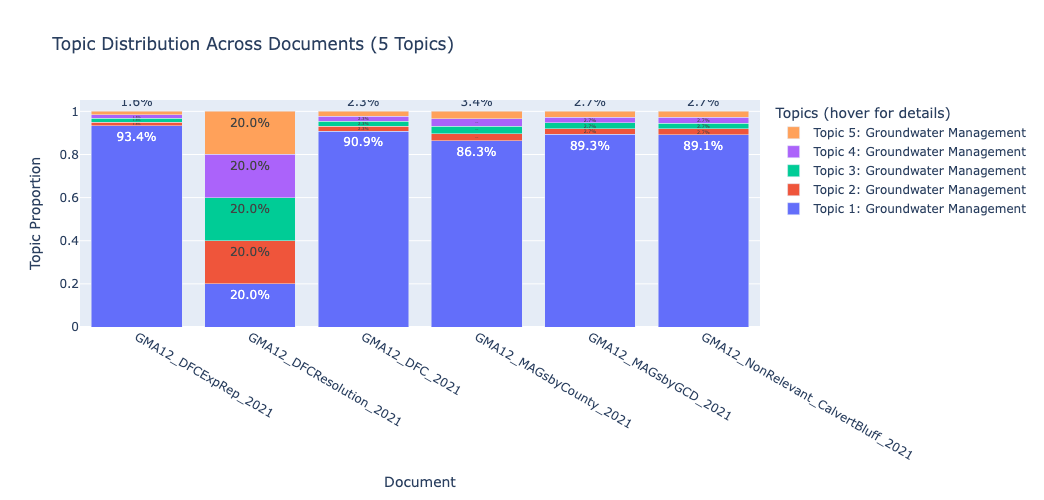

✓ Visualization complete!

Tip: change n_topics above and rerun Step 3a to compare topic structures.


In [12]:
print('Creating topic distribution chart...\n')

topic_df, fig = sbp.plot_topic_distribution(
    doc_topic_dist,
    doc_names,
    topics_info,
    n_topics=n_topics,
)
fig.show()

print('✓ Visualization complete!')
print('\nTip: change n_topics above and rerun Step 3a to compare topic structures.')



### Review the Topic Summary Table

This table gives a compact summary of the discovered topics, including their labels, descriptions, keywords, and average coverage in the corpus.


In [13]:
summary_df = sbp.build_topic_summary(topics_info, doc_topic_dist, top_words_display)
summary_df




,Topic,Label,Description,Top Keywords,Avg Coverage
0,Topic 1,Topic 1: Groundwater Management,Reports and planning documents for groundwater...,"carrizo, groundwater, aquifer, gcd, wilcox, ca...",78.2%
1,Topic 2,Topic 2: Groundwater Management,Documents related to managing and planning gro...,"regional, values, year, freestone, sparta aqui...",5.5%
2,Topic 3,Topic 3: Groundwater Management,Documents related to groundwater management ar...,"regional, values, year, freestone, sparta aqui...",5.5%
3,Topic 4,Topic 4: Groundwater Management,Documents related to groundwater management ar...,"regional, values, year, freestone, sparta aqui...",5.5%
4,Topic 5,Topic 5: Groundwater Management,Documents related to groundwater management ar...,"regional, values, year, freestone, sparta aqui...",5.5%


## Step 4: Map to the Science Backbone

This step connects the discovered topics to a scientific domain structure informed by Georgetown CSET's Emerging Technology Observatory (ETO) Map of Science.

**What changes here?**

- The notebook builds topic-specific ETO Map of Science query links
- If you export cluster metadata from ETO list view as CSV, the notebook derives the backbone from that export
- If no export is present, the tutorial falls back to the built-in example backbone

ETO Map of Science is free to use publicly, but ETO's documentation states that the underlying Research Cluster Dataset is not publicly downloadable because of licensing restrictions. In practice, the supported integration path is to use the public Map interface and its list-view CSV export rather than relying on an undocumented raw API.


### Configure Output Names

This cell sets the folder and case-study name used when the notebook writes results to disk. Adjust it if you want to save outputs under a different label.


In [14]:
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
CASE_STUDY_NAME = 'community_analysis'

print(f'✓ Output directory: {OUTPUT_DIR}')
print(f'✓ Case study name: {CASE_STUDY_NAME}')

# Point to where an ETO export would be, if available
ETO_EXPORT_PATH = OUTPUT_DIR / 'eto_map_export.csv'
print(f'✓ Will check for ETO export at: {ETO_EXPORT_PATH}')

# Optional: Filter to domain-specific disciplines
# ONLY used when USE_CUSTOM_BACKBONE = False (see cell below)
# Set to None to use all 13 UCSD disciplines
# Set to a list of discipline names to filter (e.g., groundwater-relevant)
DOMAIN_FILTER = [

]
print(f'\n✓ Domain filter (used only with default backbone): {DOMAIN_FILTER if DOMAIN_FILTER else "None (all domains)"}')

✓ Output directory: outputs
✓ Case study name: community_analysis
✓ Will check for ETO export at: outputs/eto_map_export.csv

✓ Domain filter (used only with default backbone): None (all domains)


### Build ETO Query Links

This cell turns the discovered topic keywords into ETO Map of Science search URLs. Open the list-view links, refine filters if needed, and export cluster metadata to CSV if you want an ETO-backed backbone.


### Optional: Define a Curated Backbone Scaffold

For domain-specific analysis (like groundwater management), you can define a custom UCSD scaffold with only the subdisciplines and keywords relevant to your work. This curated approach, inspired by the SUBSIDE notebooks, provides finer control over what appears in your science backbone.

Set `USE_CUSTOM_BACKBONE = True` below to enable this feature. The scaffold will replace the default 13 full disciplines with a focused set that includes only subdisciplines and terms matching your corpus domain.

**Why this matters:**
- Reduces noise from irrelevant disciplines
- Ensures consistent terminology across the backbone
- Makes network visualizations clearer
- Supports publication-ready analysis with explicit disciplinary scope

**Customization:** Edit the subdisciplines and terms in each domain below to match your own research focus.

In [17]:
# ── Optional: Curated backbone scaffold for groundwater/water resource analysis ──
# Inspired by the SUBSIDE_ScienceBackbone_Setup.ipynb approach
# 
# This scaffold filters the 13 UCSD disciplines down to only those relevant to
# your domain, with curated subdisciplines and keywords per domain.
# Set USE_CUSTOM_BACKBONE = True below to use this instead of the full default.

USE_CUSTOM_BACKBONE = True

UCSD_GROUNDWATER_SCAFFOLD = {
    "Earth Sciences": {
        "subdisciplines": [
            "Hydrology", "Hydrogeology", "Geomorphology",
            "Sedimentology", "Tectonics", "Remote Sensing",
            "Land Subsidence", "Coastal Science", "Soil Science",
        ],
        "terms": [
            "earth", "geology", "geological", "hydrology", "groundwater",
            "aquifer", "sediment", "sedimentation", "tectonic", "fault",
            "subsidence", "compaction", "consolidation", "coastal", "delta",
            "shoreline", "sea level", "insar", "interferometric",
            "remote sensing", "gps", "gnss", "lidar", "extensometer",
            "soil", "watershed", "precipitation", "drought", "oceanography",
        ],
    },
    "Chemical, Mechanical, & Civil Engineering": {
        "subdisciplines": [
            "Civil Engineering", "Geotechnical Engineering",
            "Hydraulic Engineering", "Structural Engineering",
            "Petroleum Engineering", "Mining Engineering",
        ],
        "terms": [
            "civil engineering", "geotechnical", "hydraulic", "structural",
            "foundation", "soil mechanics", "petroleum", "reservoir",
            "oil", "gas", "co2 storage", "sequestration", "mining",
            "coal", "longwall", "material", "stress", "strain",
            "finite element", "modeling", "simulation",
        ],
    },
    "Electrical Engineering & Computer Science": {
        "subdisciplines": [
            "Computer Science", "Machine Learning",
            "Artificial Intelligence", "Signal Processing",
            "Computer Vision", "Networks & Distributed Systems",
            "Data Science",
        ],
        "terms": [
            "algorithm", "computer", "computing", "machine learning",
            "deep learning", "neural network", "signal processing",
            "gis", "spatial analysis", "computer vision", "data science",
            "artificial intelligence", "modeling", "prediction",
        ],
    },
    "Social Sciences": {
        "subdisciplines": [
            "Economics", "Political Science", "Sociology",
            "Geography", "Public Policy", "Decision Science",
        ],
        "terms": [
            "economics", "economic", "political", "policy", "governance",
            "regulation", "stakeholder", "decision support", "management",
            "sociology", "geography", "community", "groundwater management",
            "gma", "resource management", "sustainability",
        ],
    },
}

print(f'✓ Curated backbone scaffold defined ({len(UCSD_GROUNDWATER_SCAFFOLD)} domains)')
for domain, node in UCSD_GROUNDWATER_SCAFFOLD.items():
    print(f"  · {domain:50s} {len(node['subdisciplines']):2d} subs · {len(node['terms']):3d} terms")


✓ Curated backbone scaffold defined (8 domains)


### Build the Science Backbone

This cell builds a multi-layer science backbone using one of two strategies:

**Strategy A: Curated Backbone (Recommended for Domain-Specific Work)**

When `USE_CUSTOM_BACKBONE = True`, the notebook uses a pre-defined UCSD scaffold tailored to your domain. This approach, inspired by the SUBSIDE notebooks, provides:
- **Explicit curation** — Only subdisciplines and keywords relevant to your work
- **Reproducibility** — Same backbone across multiple runs
- **Clarity** — Clear disciplinary scope for stakeholder review and publication

Define or edit the `UCSD_GROUNDWATER_SCAFFOLD` dict in the cell above to match your research focus. Include only domains, subdisciplines, and keywords that appear in your corpus and decision context.

**Strategy B: Auto-Filtered Backbone (Quick Exploration)**

When `USE_CUSTOM_BACKBONE = False`, the notebook:
1. Loads the default 13-discipline UCSD scaffold
2. Optionally filters by `DOMAIN_FILTER` list (removes irrelevant disciplines)
3. Optionally incorporates an ETO export if available

This is faster for initial exploration but less curated than Strategy A.

**Available Curated Domains** (Strategy A):
- **Earth Sciences** — Hydrology, Hydrogeology, Remote Sensing, Subsidence, Coastal
- **Civil/Mechanical/Chemical Engineering** — Geotechnical, Hydraulic, Petroleum, Mining
- **Computer Science** — GIS, machine learning, spatial analysis, data science
- **Social Sciences** — Policy, governance, economics, decision science

**Full UCSD Disciplines** (Strategy B, if needed):
- Math & Physics
- Chemistry
- Earth Sciences ⭐
- Biology
- Biotechnology
- Infectious Diseases
- Medical Specialties & Health Professionals
- Brain Research & Neuroscience
- Electrical Engineering & Computer Science ⭐
- Chemical, Mechanical, & Civil Engineering ⭐
- Social Sciences ⭐
- Humanities

In [18]:
# Build the science backbone directly
# Strategy:
#   1. If USE_CUSTOM_BACKBONE, apply the curated UCSD scaffold
#   2. Otherwise, load the library default and optionally filter by DOMAIN_FILTER
#   3. If ETO export exists, use it as an additional layer

print("Building science backbone...\n")

if USE_CUSTOM_BACKBONE:
    print("✓ Using curated backbone scaffold (groundwater-focused)")
    
    # Build backbone dict from the custom scaffold
    backbone_payload = {
        'schema_version': '1.0',
        'produced_by': 'semantic_bridge_cookbook (custom curated scaffold)',
        'selected_layer': 'custom',
        'layers': {
            'custom': {}
        }
    }
    
    # Materialize the custom scaffold into backbone format
    for domain, node in UCSD_GROUNDWATER_SCAFFOLD.items():
        backbone_payload['layers']['custom'][domain] = {
            'subdisciplines': node.get('subdisciplines', []),
            'terms': node.get('terms', []),
            '_source': 'Curated groundwater-focused scaffold',
        }
    
    science_backbone = backbone_payload['layers']['custom']
    print(f"✓ Loaded {len(science_backbone)} curated domains")

else:
    print("⚠ Using default UCSD scaffold (not curated)")
    
    if ETO_EXPORT_PATH.exists():
        print(f"✓ ETO export found at {ETO_EXPORT_PATH}")
        eto_clusters_df = sbp.load_eto_cluster_export(ETO_EXPORT_PATH)
        print(f"  Loaded {len(eto_clusters_df):,} clusters")
        
        # Build multi-layer backbone with ETO + UCSD
        backbone_payload = sbp.build_science_backbone_payload(
            eto_cluster_df=eto_clusters_df,
            prefer_ucsd_fields=True,
        )
        print(f"✓ Built backbone with ETO export")
    else:
        print(f"⚠ No ETO export found at {ETO_EXPORT_PATH}")
        print(f"  Building backbone with UCSD scaffold defaults")
        
        # Build backbone with defaults (UCSD + fallback)
        backbone_payload = sbp.build_science_backbone_payload()
        print(f"✓ Built backbone with defaults")
    
    # Extract the active layer
    science_backbone = sbp.selected_science_backbone(backbone_payload)
    
    # Apply domain filter if specified
    if DOMAIN_FILTER:
        n_before = len(science_backbone)
        science_backbone = {
            domain: content 
            for domain, content in science_backbone.items() 
            if domain in DOMAIN_FILTER
        }
        n_after = len(science_backbone)
        print(f"\n✓ Applied domain filter: {n_before} → {n_after} domains")
    else:
        print(f"\n✓ No domain filter applied")

print(f"\n✓ Science backbone loaded: {len(science_backbone)} domains")
if 'layers' in backbone_payload:
    print(f"  Layers available: {list(backbone_payload.get('layers', {}).keys())}")
    print(f"  Active layer: {backbone_payload.get('selected_layer')}")

# Map topics to the backbone
topic_mappings = sbp.map_topics_to_domains(topics_info)
print(f"✓ Topics mapped to domains: {len(topic_mappings)} mappings")

# Display summary
nbutils.print_science_backbone(science_backbone)
mapping_df = pd.DataFrame(topic_mappings)
nbutils.print_topic_mappings(topic_mappings)

Building science backbone...

⚠ Using default UCSD scaffold (not curated)
⚠ No ETO export found at outputs/eto_map_export.csv
  Building backbone with UCSD scaffold defaults
✓ Built backbone with defaults

✓ No domain filter applied

✓ Science backbone loaded: 13 domains
  Layers available: ['eto', 'ucsd', 'merged']
  Active layer: merged
✓ Topics mapped to domains: 5 mappings


## Science Backbone

### Math & Physics
- subdisciplines
- terms
- source
- metadata

### Chemistry
- subdisciplines
- terms
- source
- metadata

### Earth Sciences
- subdisciplines
- terms
- source
- metadata

### Biology
- subdisciplines
- terms
- source
- metadata

### Biotechnology
- subdisciplines
- terms
- source
- metadata

### Infectious Diseases
- subdisciplines
- terms
- source
- metadata

### Medical Specialties
- subdisciplines
- terms
- source
- metadata

### Health Professionals
- subdisciplines
- terms
- source
- metadata

### Brain Research
- subdisciplines
- terms
- source
- metadata

### Electrical Engineering & Computer Science
- subdisciplines
- terms
- source
- metadata

### Chemical, Mechanical, & Civil Engineering
- subdisciplines
- terms
- source
- metadata

### Social Sciences
- subdisciplines
- terms
- source
- metadata

### Humanities
- subdisciplines
- terms
- source
- metadata

## Topic-to-Domain Mappings

### Topic 1: Groundwater Management
- **Keywords:** carrizo, groundwater, aquifer, gcd, wilcox
- **Primary domain:** Water Systems
- **Secondary domain:** Governance and Decision-Making

### Topic 2: Groundwater Management
- **Keywords:** regional, values, year, freestone, sparta aquifer
- **Primary domain:** Water Systems

### Topic 3: Groundwater Management
- **Keywords:** regional, values, year, freestone, sparta aquifer
- **Primary domain:** Water Systems

### Topic 4: Groundwater Management
- **Keywords:** regional, values, year, freestone, sparta aquifer
- **Primary domain:** Water Systems

### Topic 5: Groundwater Management
- **Keywords:** regional, values, year, freestone, sparta aquifer
- **Primary domain:** Water Systems

### Science Backbone Summary

The science backbone has already been built and loaded. The code below displays the active layer and allows you to inspect all available layers.


In [19]:
# The science backbone is already built and available as:
# - science_backbone: the active layer (dict of domains)
# - backbone_payload: multi-layer structure with metadata
# - topic_mappings: topics linked to backbone domains

print("Science Backbone Summary:")
print(f"  Active layer: {backbone_payload.get('selected_layer')}")
print(f"  Total domains: {len(science_backbone)}")
print(f"  Topic mappings: {len(topic_mappings)}")
print(f"\nBackbone payload contains:")
for key in ['schema_version', 'produced_by', 'selected_layer', 'layers']:
    if key == 'layers':
        layers = backbone_payload.get(key, {})
        print(f"  {key}: {list(layers.keys())}")
    else:
        print(f"  {key}: {backbone_payload.get(key)}")


Science Backbone Summary:
  Active layer: merged
  Total domains: 13
  Topic mappings: 5

Backbone payload contains:
  schema_version: semantic-bridge-science-backbone-v1
  produced_by: semantic_bridge.mapping.eto.build_science_backbone_payload
  selected_layer: merged
  layers: ['eto', 'ucsd', 'merged']


### Optional: Explore Multi-Layer Science Backbone

The new backbone payload supports multiple layers:
- **ETO layer**: Rich scientific domains from the ETO Map of Science (if ETO export is available)
- **UCSD layer**: Established academic discipline structure from the UCSD Map of Science
- **Merged layer**: Combined ETO + UCSD for richer coverage

You can inspect each layer, save the payload for reuse, or switch between layers for different analysis contexts.


In [20]:
# Inspect the available layers and their contents
print("Available science backbone layers:")
for layer_name, layer_content in backbone_payload.get('layers', {}).items():
    domain_count = len(layer_content) if isinstance(layer_content, dict) else 0
    print(f"  • {layer_name}: {domain_count} domains")

print(f"\nActive layer: {backbone_payload.get('selected_layer')}")
print(f"Schema version: {backbone_payload.get('schema_version')}")

# Optional: Save the payload for reuse in other notebooks or workflows
# Uncomment the lines below to enable payload saving:
# 
# backbone_payload_path = OUTPUT_DIR / f'{CASE_STUDY_NAME}_backbone_payload.json'
# sbp.write_science_backbone_payload(backbone_payload, backbone_payload_path)
# print(f"\n✓ Saved backbone payload to: {backbone_payload_path}")


Available science backbone layers:
  • eto: 0 domains
  • ucsd: 13 domains
  • merged: 13 domains

Active layer: merged
Schema version: semantic-bridge-science-backbone-v1


### Optional: Switch Between Layers

If you want to use a different layer instead of the automatically selected one, uncomment and modify the code below:


In [21]:
# Example: Switch to a different layer
# Uncomment to try:
#
# LAYER_TO_USE = 'ucsd'  # Options: 'eto', 'ucsd', or 'merged'
# science_backbone_alt = backbone_payload['layers'].get(LAYER_TO_USE, {})
# print(f"\nUsing {LAYER_TO_USE} layer: {len(science_backbone_alt)} domains")
# nbutils.print_science_backbone(science_backbone_alt)


### Visualize the Science Backbone Network

This figure places the discovered topics into the science backbone as a simple network. Topic nodes use the human-readable topic labels when those are available, which makes the diagram easier to explain in a tutorial or presentation.


Creating network visualization...



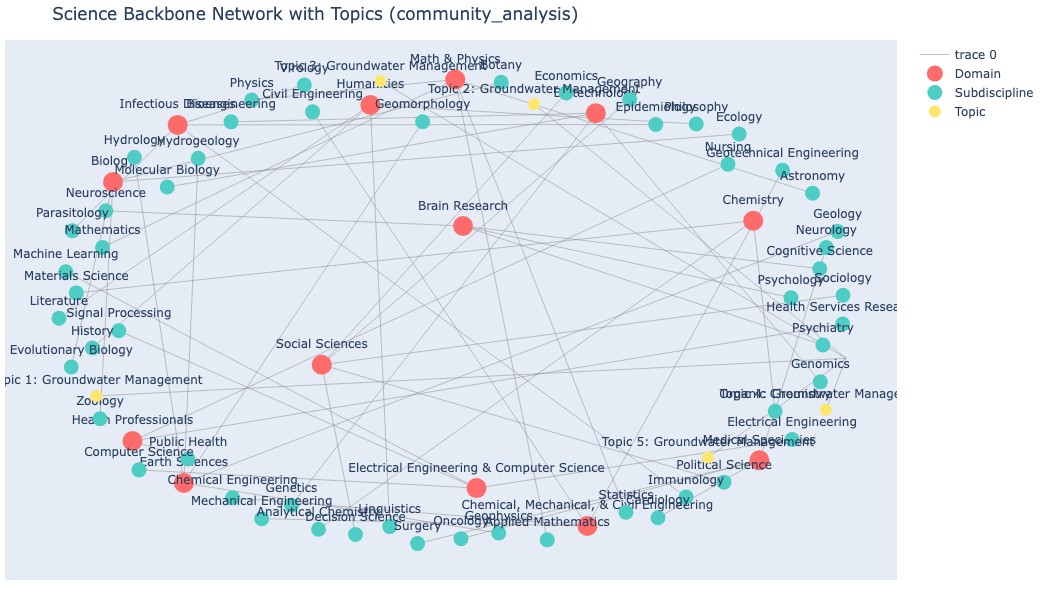

✓ Visualization complete!


In [22]:
print('Creating network visualization...\n')

graph, network_fig = sbp.create_network_figure(
    science_backbone,
    topic_mappings,
    case_study_name=CASE_STUDY_NAME,
)
network_fig.show()

print('✓ Visualization complete!')



## Step 5: Extract Decision Components

Most decision problems include a common set of elements. In this step, the notebook looks for those elements directly in the text.

We focus on:
- Goals: What are we trying to achieve?
- Objectives: Specific, measurable aims
- Decision Variables: What can we control?
- Constraints: Limits that shape what is feasible
- Indicators: How do we measure success?

### Extract Decision Components

This cell searches the corpus for common elements of a decision problem, such as goals, objectives, constraints, and indicators. It provides a first-pass structure for downstream decision analysis.


In [23]:
decision_components = sbp.extract_decision_components(transcripts, nlp)
nbutils.print_decision_components(decision_components)




## Decision Components

### Goals *(50 found)*
1. future and long term *[GMA12_DFCExpRep_2021.pdf]*
2. Desired Future Conditions *[GMA12_DFCExpRep_2021.pdf]*
3. desired future conditions *[GMA12_DFCExpRep_2021.pdf]*
4. the reasonable long-term management *[GMA12_DFCExpRep_2021.pdf]*
5. the desired conditions *[GMA12_DFCExpRep_2021.pdf]*

### Objectives *(50 found)*
1. Potential impacts *[GMA12_DFCExpRep_2021.pdf]*
2. Environmental Impacts *[GMA12_DFCExpRep_2021.pdf]*
3. ENVIRONMENTAL 
IMPACTS *[GMA12_DFCExpRep_2021.pdf]*
4. ENVIRONMENTAL  IMPACTS *[GMA12_DFCExpRep_2021.pdf]*
5. a 
positive impact *[GMA12_DFCExpRep_2021.pdf]*

### Variables *(50 found)*
1. POSGCD’s management strategy *[GMA12_DFCExpRep_2021.pdf]*
2. the key management strategy *[GMA12_DFCExpRep_2021.pdf]*
3. POSGCD Management Strategies *[GMA12_DFCExpRep_2021.pdf]*
4. water 
management strategy implementation *[GMA12_DFCExpRep_2021.pdf]*
5. regional water management strategy implementation *[GMA12_DFCExpRep_2021.pdf]*

### Constraints *(50 found)*
1. the modified budget *[GMA12_DFCExpRep_2021.pdf]*
2. The southeastern boundary *[GMA12_DFCExpRep_2021.pdf]*
3. the southeast boundary *[GMA12_DFCExpRep_2021.pdf]*
4. the limitations *[GMA12_DFCExpRep_2021.pdf]*
5. A groundwater budget *[GMA12_DFCExpRep_2021.pdf]*

### Indicators *(50 found)*
1. Input data and calibration targets *[GMA12_DFCExpRep_2021.pdf]*
2. significant measurable subsidence *[GMA12_DFCExpRep_2021.pdf]*
3. measured field data *[GMA12_DFCExpRep_2021.pdf]*
4. measurement data *[GMA12_DFCExpRep_2021.pdf]*
5. measurement 
data *[GMA12_DFCExpRep_2021.pdf]*

### Compare Decision Component Counts

This bar chart summarizes how many items were found for each decision-component type. It helps you see which parts of the decision framing are well represented in the text.


In [ ]:
component_counts_map = sbp.component_counts(decision_components)
component_fig = sbp.plot_component_distribution(component_counts_map)
component_fig.show()

print('✓ Visualization complete!')



### Build a Reusable Decision-Component Table

This cell turns the extracted decision components into a tabular structure that can be filtered, exported, or reused later in the notebook.


In [ ]:
USE_LLM_COMPONENT_REWRITE = True

components_df = sbp.component_table(decision_components)

readable_components_df = sbp.improve_decision_component_readability_with_llm(
    components_df=components_df,
    model=TOPIC_LABELER_MODEL,
    api_key=TOPIC_LABELER_API_KEY,
    base_url=TOPIC_LABELER_BASE_URL,
)

readable_display_df = sbp.human_readable_component_table(readable_components_df)
readable_display_df


In [ ]:
readable_display_df.iloc[246]['Evidence Context']

In [ ]:
readable_display_df.iloc[246]['Rewrite Note']

## Step 6: Link to Scientific Variables

**What are Scientific Variable Objects (SVOs)?**

An SVO is a standardized description of a measurable quantity.

It helps translate everyday language into scientific variables that can be observed, modeled, or retrieved from data systems.

In this tutorial, the scientific-variable vocabulary now comes from the MINT variable presentations API when available, with a small local fallback vocabulary for offline use.

Each SVO-style entry can include:
- Variable Name: What we measure
- Units: How we measure it
- Data Source: Where the variable definition came from
- Standard Name: Scientific terminology
- Domain: A broad scientific grouping when available

This step creates a translation layer between stakeholder language and measurable scientific concepts.



### Load the Scientific-Variable Vocabulary

This cell retrieves scientific variable definitions from the MINT API when available. If the live service is unavailable, it falls back to a smaller local tutorial vocabulary so the workflow can continue.


In [ ]:
USE_MINT_SVO_VOCABULARY = True
MINT_SVO_API_BASE_URL = MINT_API_BASE_URL
MINT_SVO_USERNAME = MINT_USERNAME

try:
    if USE_MINT_SVO_VOCABULARY:
        svo_vocabulary = sbp.fetch_mint_svo_vocabulary(
            base_url=MINT_SVO_API_BASE_URL,
            username=MINT_SVO_USERNAME,
            per_page=MINT_SVO_PER_PAGE,
            max_pages=MINT_SVO_MAX_PAGES,
        )
        svo_source = 'MINT variablepresentations API'
    else:
        raise RuntimeError('Configured to use local fallback vocabulary.')
except Exception as exc:
    print(f'Falling back to local demo SVO vocabulary: {exc}')
    svo_vocabulary = sbp.default_svo_vocabulary()
    svo_source = 'Local fallback vocabulary'

nbutils.print_svo_vocabulary_preview(svo_vocabulary, svo_source)


### SVO Matching Options

Use these controls to tighten or loosen how natural-language terms are matched to scientific variables.

- `SVO_MIN_KEYWORD_WORDS` sets the minimum number of words required for an automatic match.
- `SVO_SINGLE_WORD_ALLOWLIST` lets you preserve a small set of strong scientific one-word terms.


### Control How Strictly SVOs Are Matched

Use these settings to decide how cautious the notebook should be when linking natural-language terms to scientific variables. Stricter settings reduce false positives; looser settings can recover more matches.


In [ ]:
SVO_MIN_KEYWORD_WORDS = 2
SVO_SINGLE_WORD_ALLOWLIST = {
    'subsidence',
    'precipitation',
    'salinity',
    'groundwater',
}

print(f'Minimum keyword length: {SVO_MIN_KEYWORD_WORDS} words')
print(f'Allowed single-word scientific terms: {sorted(SVO_SINGLE_WORD_ALLOWLIST)}')



### Link Narrative Terms to Scientific Variables

This cell matches terms from the corpus to scientific variables in the vocabulary. The result is a bridge between everyday language and measurable scientific concepts.


In [ ]:
svo_mappings = sbp.create_svo_mappings(
    transcripts,
    svo_vocabulary,
    min_keyword_words=SVO_MIN_KEYWORD_WORDS,
    allow_single_word_keywords=SVO_SINGLE_WORD_ALLOWLIST,
)
unique_mappings = sbp.deduplicate_svo_mappings(svo_mappings)
svo_df = sbp.svo_table(unique_mappings)
nbutils.print_svo_mapping_summary(unique_mappings)




### Optional MINT Queries for Each Topic

This optional step uses the MINT catalog to suggest which scientific domains and tags are worth querying next for each topic.


### Recommend MINT Models for Matched Variables

This optional cell suggests MINT models or model configurations that appear relevant to the scientific variables found in the corpus. Treat these as candidate starting points for further review.


In [ ]:
USE_MINT_MODEL_RECOMMENDATIONS = True
MINT_MODEL_API_BASE_URL = MINT_API_BASE_URL
MINT_MODEL_USERNAME = MINT_USERNAME
MINT_MODELS_PER_SVO = 2

model_recommendations = []
model_recommendations_df = pd.DataFrame()

if USE_MINT_MODEL_RECOMMENDATIONS and unique_mappings:
    try:
        mint_model_candidates = sbp.fetch_mint_model_candidates(
            base_url=MINT_MODEL_API_BASE_URL,
            username=MINT_MODEL_USERNAME,
            per_page=MINT_MODEL_PER_PAGE,
            max_pages=MINT_MODEL_MAX_PAGES,
        )
        model_recommendations = sbp.recommend_models_for_svo_mappings(
            unique_mappings,
            mint_model_candidates,
            recommendations_per_svo=MINT_MODELS_PER_SVO,
        )
        model_recommendations_df = pd.DataFrame(model_recommendations)
        nbutils.print_svo_model_recommendations(model_recommendations_df)
    except Exception as exc:
        print(f'Could not retrieve MINT model recommendations: {exc}')
else:
    print('Skipping MINT model recommendations.')


### Visualize Scientific Variables by Domain

This chart summarizes which scientific domains are represented by the matched variables. It gives a quick sense of where the narrative is strongest in scientific terms.


In [ ]:
_, sunburst_fig, domain_counts = sbp.plot_svo_sunburst(unique_mappings)
sunburst_fig.show()
nbutils.print_domain_counts(domain_counts)




## Interpreting the Sunburst Figure

The **Scientific Variables by Domain** sunburst chart shows how stakeholder narratives connect to scientific concepts.

### What the figure shows

**Inner ring:** scientific domains such as Hydrology, Climate Science, Social Science, Economics, Engineering, and Oceanography

**Outer ring:** individual scientific variables nested within each domain, such as:
- `water_level` and `groundwater_level` under Hydrology
- `precipitation` under Climate Science  
- `economic_damage` under Economics
- `infrastructure_vulnerability` under Engineering

**Segment size:** proportional to how frequently each domain or variable appears in the mapped text

### What it tells you

1. **Problem scope:** which scientific disciplines are most relevant to the stakeholder concerns

2. **Data needs:** what kinds of measurements, datasets, or monitoring systems may support the decision process

3. **Interdisciplinary structure:** whether the problem is concentrated in one field or spread across several domains

4. **Stakeholder priorities:** which measurable concepts best reflect the language people use to describe the problem

### Why this matters for TACC workflows

This figure helps you identify:
- Which computational models you need (hydrological, economic, infrastructure assessment)
- What datasets to access from TACC resources or external sources
- Which scientific experts should be engaged
- How to structure your decision support system to match stakeholder mental models

In short, it shows which science is needed to answer the questions the community is asking.

## Step 7: Generate Summary Report

In the final step, the notebook writes a short report that summarizes the topics, mappings, decision components, and generated outputs.

### Export the Results

This cell writes the key outputs of the analysis to disk, including tables, figures, and a summary report. It is the main checkpoint for saving the notebook results.


In [ ]:
output_files = sbp.write_outputs_table(
    OUTPUT_DIR,
    CASE_STUDY_NAME,
    topic_mappings,
    components_df,
    svo_df,
    network_fig,
    sunburst_fig,
)

# Save the multi-layer science backbone payload for reuse in other workflows
backbone_payload_path = OUTPUT_DIR / f'{CASE_STUDY_NAME}_backbone_payload.json'
sbp.write_science_backbone_payload(backbone_payload, backbone_payload_path)
print(f'✓ Saved science backbone payload to: {backbone_payload_path}')

summary = sbp.build_summary_report(
    CASE_STUDY_NAME,
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    unique_mappings,
    svo_df,
)
report_path = sbp.write_report(OUTPUT_DIR, CASE_STUDY_NAME, summary)
nbutils.print_export_summary(
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    unique_mappings,
    output_files,
    report_path,
)

### Preview the Summary Report

Use this cell to inspect the beginning of the generated report before sharing it or moving it into another workflow.


In [ ]:
nbutils.print_report_preview(summary, report_path)




### Create a Quick Reference Table

This final table condenses the major outputs of the workflow into a single summary view. It can be useful for presentations, handoffs, or rapid review.


In [ ]:
quick_ref = sbp.build_quick_reference(
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    svo_vocabulary,
    unique_mappings,
    output_files,
)

quick_ref_path = OUTPUT_DIR / f'{CASE_STUDY_NAME}_summary_table.csv'
quick_ref.to_csv(quick_ref_path, index=False)
quick_ref




### Optional: Load a Saved Science Backbone in Future Notebooks

You can reuse the science backbone payload in other notebooks or workflows:

```python
# Load a previously saved backbone payload
backbone_payload = sbp.read_science_backbone_payload(
    Path('outputs') / 'community_analysis_backbone_payload.json'
)

# Extract the active layer
science_backbone = sbp.selected_science_backbone(backbone_payload)

# Access other layers as needed
merged_backbone = backbone_payload['layers'].get('merged', {})
ucsd_backbone = backbone_payload['layers'].get('ucsd', {})
eto_backbone = backbone_payload['layers'].get('eto', {})
```


## Wrap-Up

You have completed the semantic bridge analysis workflow.

### What you learned
- How to extract topics from text automatically
- How to map narratives to scientific domains
- How to identify decision components
- How to link language to measurable variables

### How to apply this to your own work
1. Replace sample data with your own documents
2. Customize domains in `science_backbone`
3. Expand `svo_vocabulary`
4. Adjust the `n_topics` parameter
5. Re-run and validate with stakeholders

### Output files
All results are saved in the `outputs/` folder:
- CSV files for further analysis
- HTML visualizations for sharing
- Markdown report for documentation

### Next steps
- Review the generated outputs with domain experts and stakeholders
- Refine the science backbone and variable mappings for your domain
- Connect the results to downstream datasets, models, or decision tools

This workflow is designed to preserve stakeholder language while connecting it to scientific and engineering analysis.